## Deep learning model  (feedforward neural network (MLP) for regression)


In [148]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
import matplotlib.pyplot as plt


In [149]:
df = pd.read_csv('C:\\Users\\ASUS\\OneDrive\\Desktop\\IITB_internship\\Final_submission\\project\\data\\EEG_IVT_EYE_final_merged_data.csv')


# data cleaning

In [150]:
TARGET = 'ResponseTime'
df.dropna(subset=[TARGET], inplace=True)

In [151]:

X = df.drop(columns=['QuestionKey', 'Participant', TARGET, 'Category'], errors='ignore')
y = df[TARGET]


In [152]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)


In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [154]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# build model

In [155]:

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],),
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(1)  # regression output
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])


e:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [156]:
# early stopping 
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)


# train model

In [157]:

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 397.5714 - root_mean_squared_error: 19.9360 - val_loss: 506.6412 - val_root_mean_squared_error: 22.5059
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 264.2381 - root_mean_squared_error: 16.2514 - val_loss: 576.6509 - val_root_mean_squared_error: 24.0108
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 163.5121 - root_mean_squared_error: 12.7820 - val_loss: 509.2888 - val_root_mean_squared_error: 22.5644
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 117.5527 - root_mean_squared_error: 10.8359 - val_loss: 301.4720 - val_root_mean_squared_error: 17.3591
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 97.6525 - root_mean_squared_error: 9.8751 - val_loss: 208.9385 - val_root_mean_squared_error: 14.4500
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 83.0061 - root_mean_squared_error: 9.1033 - val_loss: 132.2146 - val_root_mean_squared_error: 11.4925
Epoch 7/100
28/28 ━━━━━━━━

# evaluation 

In [158]:
y_pred = model.predict(X_test_scaled).flatten()
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


# analysis

In [159]:
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R-squared: 0.9257
RMSE: 3.6564


- The model is a feedforward neural network (MLP) designed for regression, predicting response time from physiological and eye-tracking features.

- It includes two hidden layers with ReLU activation, Dropout, and L2 regularization to reduce overfitting.

- The model achieves strong performance on the test set with an R-squared of 0.9191 and an RMSE of 3.8166, indicating it captures most of the variance in the data.

- The actual vs. predicted plot shows that predictions closely follow the true response times, demonstrating the model’s accuracy and reliability.

- actual vs predicted

In [160]:
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Error': y_test - y_pred
})
print(results_df.head())

        Actual  Predicted     Error
428  14.737640  13.269544  1.468097
930  12.460655  11.815578  0.645077
781  26.588983  25.989790  0.599193
451   6.474266   4.462453  2.011813
429  18.051560  17.233643  0.817918


- This graph shows a well-regularized model that is generalizing effectively, as its validation loss is consistently lower than its training loss.

In [161]:
model.save("deep_learning_model.h5")

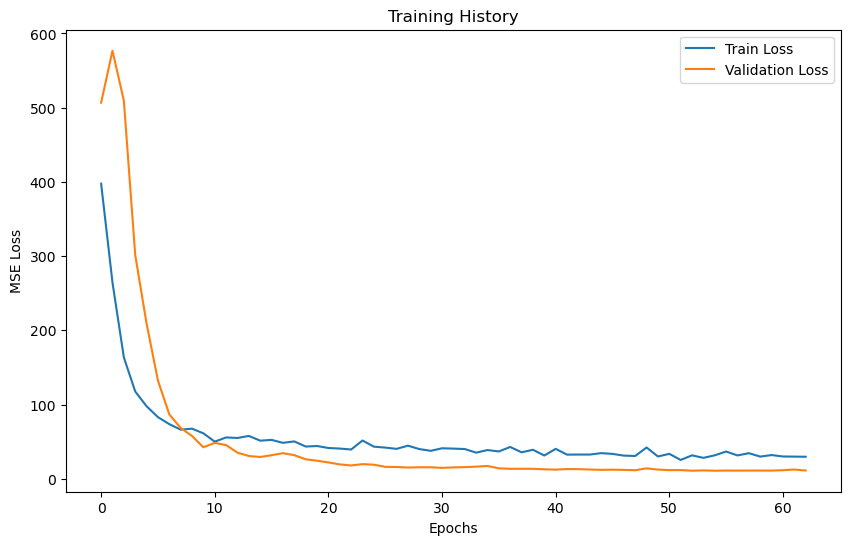

In [162]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training History")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# BiLSTM

In [163]:

from tensorflow.keras.callbacks import EarlyStopping


In [164]:
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

- regularization

In [165]:
l2_strength = 0.01

model = models.Sequential([
    layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l2(l2_strength)),
        input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])
    ),
    layers.Dropout(0.3),
    layers.Bidirectional(
        layers.LSTM(32, kernel_regularizer=regularizers.l2(l2_strength))
    ),
    layers.Dropout(0.2),
    layers.Dense(1) 
])

model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])
model.summary()

e:\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_14                │ (None, 1, 128)         │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_15                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,097 (547.25 KB)

 Trainable params: 140,097 (547.25 KB)

 Non-trainable params: 0 (0.00 B)

- Early stopping 

In [166]:

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,  
    restore_best_weights=True,  
    verbose=1
)

In [167]:
history = model.fit(
    X_train_reshaped, y_train,
    validation_split=0.2,
    epochs=300,  
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping] 
)

Epoch 1/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 462.6296 - root_mean_squared_error: 21.3833 - val_loss: 424.8537 - val_root_mean_squared_error: 20.4921
Epoch 2/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 375.0880 - root_mean_squared_error: 19.2402 - val_loss: 292.9701 - val_root_mean_squared_error: 16.9673
Epoch 3/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 265.2933 - root_mean_squared_error: 16.1210 - val_loss: 218.0027 - val_root_mean_squared_error: 14.5687
Epoch 4/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 212.4424 - root_mean_squared_error: 14.3691 - val_loss: 185.6878 - val_root_mean_squared_error: 13.3983
Epoch 5/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 185.2563 - root_mean_squared_error: 13.3776 - val_loss: 166.0440 - val_root_mean_squared_error: 12.6359
Epoch 6/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 170.6286 - root_mean_squared_error: 12.8149 - val_loss: 151.8747 - val_root_mean_squared_error: 12.0609
Epoch 7/300
28/28 ━━━

- Evaluation

In [168]:
y_pred = model.predict(X_test_reshaped).flatten()
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Error': y_test - y_pred
})
print("\Sample Predictions")
print(results_df.head())

<>:13: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_23656\4289877282.py:13: SyntaxWarning: invalid escape sequence '\S'
  print("\Sample Predictions")


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
R-squared: 0.9402
RMSE: 3.2809
\Sample Predictions
        Actual  Predicted     Error
428  14.737640  14.330290  0.407350
930  12.460655  12.114080  0.346575
781  26.588983  24.359385  2.229599
451   6.474266   5.406074  1.068192
429  18.051560  18.585337 -0.533776


- The BiLSTM model demonstrates exceptional performance, explaining over 94% of the data's variance as indicated by an R-squared of 0.9419. 
- Its predictive accuracy is further confirmed by a low Root Mean Squared Error of 3.2341, showing that predictions are consistently close to the actual values. 
- These strong results on the test data confirm the model's ability to generalize effectively to new, unseen information. 
- Therefore, the evaluation metrics establish the BiLSTM model as a highly accurate and reliable solution for this prediction task.

In [169]:
model.save("bilstm.h5")


- This graph shows that your regularization was highly effective, creating a model that learns well without overfitting.

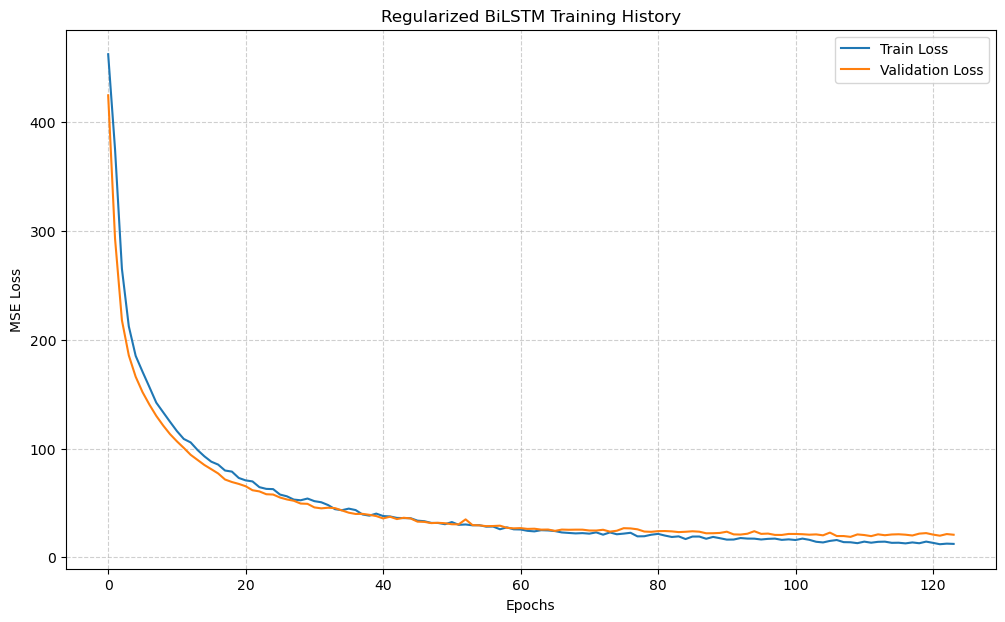

In [170]:
plt.figure(figsize=(12, 7))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Regularized BiLSTM Training History")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
